<a href="https://colab.research.google.com/github/Nick738996/Algoritmos-de-Optimizacion/blob/main/seminario_Algoritmos_Brandon_Gomez_Convocatoria2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Brandon Nick Gomez Aya<br>
Url: https://github.com/Nick738996/Algoritmos-de-Optimizacion/blob/main/seminario_algoritmos_brandon_gomez_convocatoria2.ipynb<br>
Problema:
> 1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de La Liga<br>
>3. Combinar cifras y operaciones

**Problema escogido:** Sesiones de doblaje.

## Descripción del problema

**Problema 1. Organizar sesiones de doblaje (I)**

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos. Los actores cobran todos la misma cantidad por cada día que se desplazan al estudio, independientemente del número de tomas que se graben. No es posible grabar más de **6 tomas por día**. El objetivo es planificar las sesiones por día de manera que el gasto por servicios de los actores sea el menor posible.

**Datos:**
- Número de actores: 10
- Número de tomas: 30
- Matriz Actores/Tomas: https://bit.ly/36D8IuK
  - `1` indica que el actor participa en la toma
  - `0` en caso contrario

(*) La respuesta es obligatoria

---

## Nota sobre el alcance del trabajo

Nota sobre el alcance del trabajo
Este trabajo se presenta de forma individual y fuera del plazo ordinario, conforme a lo acordado con el tutor. Para compensar la carga de trabajo correspondiente a una entrega en pareja, se ha ampliado el alcance del seminario: se desarrolla un marco combinatorio formal basado en la teoría de particiones de conjuntos, se implementan dos enfoques algorítmicos comparados (heurística voraz como línea base y Algoritmo Genético como propuesta principal) y se incluye un análisis de robustez estadística sobre múltiples ejecuciones.


In [37]:
# Imports globales utilizados a lo largo del notebook
import math
import random
import time
import statistics
from functools import lru_cache
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import auth
import gspread
from google.auth import default

# Semilla global por defecto para que las ejecuciones sean reproducibles
SEMILLA = 42
random.seed(SEMILLA)

# Carga del dataset desde Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

nombre_hoja = 'Copia de Copy of Datos problema doblaje(30 tomas, 10 actores)'

try:
    # Abrir la hoja de cálculo por nombre
    sh = gc.open(nombre_hoja)
    worksheet = sh.get_worksheet(0)
    data = worksheet.get_all_values()

    # Convertir a DataFrame (la cabecera real está en la segunda fila, índice 1)
    df = pd.DataFrame(data[2:], columns=data[1])

    # Nos quedamos sólo con las columnas de los 10 actores
    columnas_actores = [str(i) for i in range(1, 11)]

    # Estructura de trabajo: matriz binaria como lista de listas
    # Limpiamos espacios y convertimos a int
    matriz_tomas = df[columnas_actores].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int).values.tolist()

    print("--- DATASET CARGADO DESDE GOOGLE SHEETS ---")
    print(f"Total de tomas:   {len(matriz_tomas)}")
    print(f"Total de actores: {len(matriz_tomas[0])}")
    print("\nEjemplo — Toma 1 (1=participa, 0=no participa):")
    print(matriz_tomas[0])
except Exception as e:
    print(f"ERROR: No se pudo cargar la hoja de cálculo. {e}")
    print(f"Asegúrate de que el nombre '{nombre_hoja}' sea correcto en tu Drive.")

--- DATASET CARGADO DESDE GOOGLE SHEETS ---
Total de tomas:   32
Total de actores: 10

Ejemplo — Toma 1 (1=participa, 0=no participa):
[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.




**Respuesta**

El problema **no** es de permutaciones ni de variaciones, sino un problema de **partición de un conjunto finito** (Set Partitioning Problem). El motivo es el siguiente: el coste no depende del orden de los días — que la jornada del lunes sea la "primera" y la del martes la "segunda" no altera el número de actores únicos que asisten a cada una. Cualquier formulación que cuente como soluciones distintas dos planificaciones que difieran únicamente en el etiquetado de los días estaría sobre-contando. Por tanto, el espacio correcto son las particiones del conjunto de 30 tomas en bloques no ordenados con la restricción de que ningún bloque exceda 6 elementos.

### Números de Stirling de Segunda Especie

El **Número de Stirling de Segunda Especie**, denotado $S(n,k)$, cuenta el número de formas de particionar un conjunto de $n$ elementos en exactamente $k$ subconjuntos no vacíos no ordenados. Verifica la recurrencia:

$$S(n,k) = k\cdot S(n-1,k) + S(n-1,k-1), \qquad S(n,0)=[n=0],\ S(n,n)=1.$$

Su fórmula cerrada por inclusión-exclusión es:

$$S(n,k) = \frac{1}{k!}\sum_{j=0}^{k}(-1)^{j}\binom{k}{j}(k-j)^{n}.$$

Esta expresión deja explícito por qué $D^N$ sobre-cuenta el espacio: $k^{n}$ es el número de funciones $f:\{1,\dots,n\}\to\{1,\dots,k\}$ (asignaciones ordenadas de tomas a días etiquetados), y al dividir entre $k!$ y aplicar inclusión-exclusión se eliminan tanto el etiquetado de los días como las asignaciones que dejan días vacíos.

### Números de Bell

El **Número de Bell** $B_n$ cuenta el **total** de particiones de un conjunto de $n$ elementos, sumando sobre todas las cardinalidades posibles del número de bloques:

$$B_n = \sum_{k=0}^{n} S(n,k).$$

$B_n$ representa el tamaño del espacio de soluciones **sin** restricción de capacidad: cuántas formas hay de agrupar las $n$ tomas en cualquier número de jornadas asumiendo únicamente que cada jornada agrupa al menos una toma. Para nuestro problema: $B_{30}\approx 8{,}47\times 10^{23}$.

### Espacio acotado por la restricción de capacidad $|A_i|\le 6$

La restricción real impone que ningún día contenga más de 6 tomas. Denoto por $P^{\le 6}(N)$ el espacio admisible. Acotando los días posibles:

- **Mínimo de días necesarios:** $k_{\min}=\lceil 30/6\rceil = 5$.
- **Máximo de días útil:** $k_{\max}=30$ (una toma por día; carece de sentido económico pero es admisible).

Para contar $P^{\le 6}(30)$ se utiliza la equivalencia: una partición de conjunto está determinada por (a) la **composición de tamaños** $\lambda=(\lambda_1\ge\dots\ge\lambda_k)$ —una partición entera de $N$ con partes $\le 6$—, y (b) cómo se reparten los elementos concretos. El número de particiones de conjunto que realizan una composición $\lambda$ dada es:

$$\frac{N!}{\prod_{i=1}^{k}\lambda_i!\cdot \prod_{j\ge 1} m_j!}$$

donde $m_j$ es el número de partes de tamaño $j$ (el factor $\prod m_j!$ corrige las permutaciones entre bloques del mismo tamaño, que son indistinguibles porque los días no están ordenados).

Sumando sobre todas las particiones enteras de $N=30$ con partes $\le 6$:

$$|P^{\le 6}(30)| = \sum_{\substack{\lambda\vdash 30\\ \lambda_i\le 6}} \frac{30!}{\prod_i \lambda_i!\cdot \prod_j m_j!}.$$

La siguiente celda calcula explícitamente $S(30,k)$, $B_{30}$ y $|P^{\le 6}(30)|$, desglosando cuántas particiones admisibles hay para cada número de días $k\in\{5,\dots,30\}$.


In [38]:
# Números de Stirling de Segunda Especie S(n,k)
@lru_cache(maxsize=None)
def stirling2(n, k):
    """S(n,k) por recurrencia: S(n,k) = k*S(n-1,k) + S(n-1,k-1)."""
    if k == 0:
        return 1 if n == 0 else 0
    if k > n or k < 0:
        return 0
    if k == n or k == 1:
        return 1
    return k * stirling2(n - 1, k) + stirling2(n - 1, k - 1)

# Número de Bell B(n) = suma_k S(n,k)
def bell(n):
    return sum(stirling2(n, k) for k in range(n + 1))

# Particiones del CONJUNTO con restricción |A_i| <= max_size
def particiones_enteras(n, max_parte):
    """Genera particiones enteras de n con partes <= max_parte (orden decreciente)."""
    def helper(restante, mayor):
        if restante == 0:
            yield ()
            return
        for parte in range(min(restante, mayor), 0, -1):
            for sub in helper(restante - parte, parte):
                yield (parte,) + sub
    yield from helper(n, max_parte)

def particiones_conjunto_restringidas(N, max_size):
    """
    Cuenta las particiones del conjunto {1,...,N} donde cada bloque tiene
    tamaño <= max_size. Devuelve (dict por k, total).
    """
    total_por_k = {}
    total = 0
    for lam in particiones_enteras(N, max_size):
        k = len(lam)
        mult = {}
        for p in lam:
            mult[p] = mult.get(p, 0) + 1
        denom = 1
        for p in lam:
            denom *= math.factorial(p)
        for m in mult.values():
            denom *= math.factorial(m)
        cuenta = math.factorial(N) // denom
        total_por_k[k] = total_por_k.get(k, 0) + cuenta
        total += cuenta
    return total_por_k, total

# CÁLCULOS PARA N=30, MAX=6
N, MAX = 30, 6

print("=" * 68)
print("ESPACIO DE SOLUCIONES — MARCO DE PARTICIONES DE CONJUNTO")
print("=" * 68)

# Algunos Stirling representativos
print(f"\nS(30, 5)  = {stirling2(30, 5):,}")
print(f"S(30, 6)  = {stirling2(30, 6):,}")
print(f"S(30, 10) = {stirling2(30, 10):,}")

# Espacio TOTAL sin restricción de capacidad: Número de Bell B(30)
B30 = bell(30)
print(f"\nB(30) = SUM_k S(30,k) = {B30:,}")
print(f"      ≈ {B30:.3e}     (espacio total sin restricción de capacidad)")

# Espacio ACOTADO con restricción |A_i| <= 6
por_k, total_acotado = particiones_conjunto_restringidas(N, MAX)
k_min = math.ceil(N / MAX)
print(f"\nRestricción: |A_i| <= 6   →   k_min = {k_min},   k_max = {N}")
print(f"\nDesglose por número de días k (solo k con particiones válidas):")
for k in sorted(por_k.keys()):
    print(f"   k = {k:2d} días   →   {por_k[k]:>30,} particiones")
print(f"\n|P^≤6(30)| = TOTAL particiones válidas = {total_acotado:,}")
print(f"           ≈ {total_acotado:.3e}")

# Caso 5 días × 6 tomas: debe coincidir con la multinomial clásica
caso_5x6 = math.factorial(30) // (math.factorial(6) ** 5 * math.factorial(5))
print(f"\nComprobación caso 5 días × 6 tomas:")
print(f"   30! / ((6!)^5 · 5!) = {caso_5x6:,}")
print(f"   por_k[5]            = {por_k[5]:,}")
print(f"   Coinciden? {caso_5x6 == por_k[5]}")


ESPACIO DE SOLUCIONES — MARCO DE PARTICIONES DE CONJUNTO

S(30, 5)  = 7,713,000,216,608,565,075
S(30, 6)  = 299,310,102,746,948,685,757
S(30, 10) = 173,373,343,599,189,364,594,756

B(30) = SUM_k S(30,k) = 846,749,014,511,809,332,450,147
      ≈ 8.467e+23     (espacio total sin restricción de capacidad)

Restricción: |A_i| <= 6   →   k_min = 5,   k_max = 30

Desglose por número de días k (solo k con particiones válidas):
   k =  5 días   →           11,423,951,396,577,720 particiones
   k =  6 días   →       27,141,023,727,989,347,176 particiones
   k =  7 días   →    1,247,092,322,221,582,801,965 particiones
   k =  8 días   →   13,637,343,679,657,420,597,875 particiones
   k =  9 días   →   60,705,648,218,644,947,402,885 particiones
   k = 10 días   →   139,641,497,056,637,478,658,756 particiones
   k = 11 días   →   189,690,129,306,340,866,102,900 particiones
   k = 12 días   →   165,547,620,103,335,670,775,575 particiones
   k = 13 días   →   98,298,768,115,079,797,990,725 particion

Modelo para el espacio de soluciones<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


**Respuesta**

La elección de la estructura de datos se separa en dos decisiones independientes: cómo representar los **datos de entrada** y cómo representar una **solución**.

### Datos de entrada: matriz tomas × actores

Una **matriz binaria** $M\in\{0,1\}^{30\times 10}$ donde $M[t][a]=1$ si el actor $a$ participa en la toma $t$, y $0$ en caso contrario. En Python se representa como `list[list[int]]` (o `np.ndarray` si se busca rendimiento adicional). Esta forma soporta acceso por índice en tiempo constante $O(1)$ —del tipo `M[t][a]`— y es suficiente dado el tamaño moderado del dataset ($30\times 10 = 300$ celdas). No hay justificación para complicar la representación con diccionarios u otras estructuras: el acceso aleatorio es tan común que la matriz gana en todos los criterios relevantes.

### Representación de una solución

Aquí se manejan **dos representaciones equivalentes** que se usarán según el algoritmo:

**(a) Lista de listas de tomas** (planificación explícita):
```
planificacion = [[0, 5, 12, ...], [1, 7, 9, ...], ...]
```
donde la $j$-ésima sublista contiene los índices de las tomas asignadas al día $j$. Esta es la representación que usa el algoritmo voraz, ya que construye la solución incrementalmente día por día. La validación de la restricción de capacidad se hace mediante `len(planificacion[j]) <= 6` en tiempo constante, y el coste se evalúa recorriendo los actores únicos por sublista.

**(b) Cromosoma plano** (asignación por toma):
```
cromosoma[t] = d        # día asignado a la toma t
```
de longitud fija $N=30$ con genes enteros en $[0,\,d_{\max}-1]$. Esta es la representación que usa el **Algoritmo Genético** porque permite aplicar operadores estándar (cruce y mutación) directamente sobre un vector de enteros con dominio acotado, sin necesidad de codificaciones por permutación complejas.

Ambas representaciones son **biyectivas** salvo etiquetado de días, y a lo largo del notebook se utilizan funciones explícitas de conversión entre ellas (`cromosoma_a_planificacion`).

### Por qué se descarta una sola estructura "talla única"

Inicialmente parecería razonable usar únicamente la representación (a) para todo el problema. Sin embargo, intentar aplicar operadores genéticos directamente sobre `list[list[int]]` obliga a operadores de cruce de tamaño variable y a operadores de mutación que muevan tomas entre sublistas con verificaciones de capacidad. Es más limpio mantener dos representaciones según el algoritmo y convertir cuando haga falta.

La celda anterior ya cargó el dataset en `matriz_tomas` siguiendo la representación (a).


In [39]:
# Inspección rápida de la matriz cargada
print("RESUMEN DE LA ESTRUCTURA")
print(f"Filas (tomas)   : {len(matriz_tomas)}")
print(f"Columnas (actores): {len(matriz_tomas[0])}")

# Actores por toma (suma de la fila)
actores_por_toma = [sum(fila) for fila in matriz_tomas]
print(f"\nActores por toma — min: {min(actores_por_toma)}, "
      f"max: {max(actores_por_toma)}, "
      f"media: {sum(actores_por_toma)/len(actores_por_toma):.2f}")

# Apariciones por actor (suma de la columna)
apariciones_por_actor = [sum(fila[a] for fila in matriz_tomas)
                         for a in range(len(matriz_tomas[0]))]
print(f"\nApariciones por actor (cuántas tomas tiene cada uno):")
for a, n in enumerate(apariciones_por_actor):
    print(f"  Actor {a+1}: {n} tomas")


RESUMEN DE LA ESTRUCTURA
Filas (tomas)   : 32
Columnas (actores): 10

Actores por toma — min: 0, max: 94, media: 5.88

Apariciones por actor (cuántas tomas tiene cada uno):
  Actor 1: 44 tomas
  Actor 2: 28 tomas
  Actor 3: 26 tomas
  Actor 4: 30 tomas
  Actor 5: 22 tomas
  Actor 6: 16 tomas
  Actor 7: 6 tomas
  Actor 8: 8 tomas
  Actor 9: 4 tomas
  Actor 10: 4 tomas


Según el modelo para el espacio de soluciones<br>
(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

**Respuesta**

Es un problema de **minimización**.

Cada día de grabación, los actores que asisten cobran (independientemente del número de tomas que graben), por lo que el coste de una jornada equivale al **número de actores únicos** que asisten ese día. El coste total es la suma del coste de cada jornada.

Formalmente, dada una partición admisible $\mathcal{P}=\{B_1,B_2,\dots,B_D\}$ del conjunto de tomas (con $|B_j|\le 6$ para todo $j$), si denotamos por $A(B_j)\subseteq\{1,\dots,10\}$ el conjunto de actores que participan en alguna toma de $B_j$, la **función objetivo** es:

$$\boxed{\ Z(\mathcal{P}) = \sum_{j=1}^{D} |A(B_j)|\ }$$

y se busca:

$$\mathcal{P}^{*} = \underset{\mathcal{P}\in P^{\le 6}(30)}{\arg\min}\ Z(\mathcal{P}).$$

Si se trabaja con la representación de cromosoma plano $c\in\{0,\dots,d_{\max}-1\}^{N}$, basta con agrupar las tomas por el valor de $c[t]$ para obtener los bloques $B_j$, y la función objetivo se evalúa idénticamente.


In [40]:
def costo_dia(tomas_dia, matriz_tomas):
    """
    Coste de un día: número de actores únicos que asisten.
    tomas_dia: lista con los índices de las tomas asignadas a ese día.
    """
    actores = set()                                # un set evita duplicados
    for toma in tomas_dia:
        for actor_idx, participa in enumerate(matriz_tomas[toma]):
            if participa == 1:
                actores.add(actor_idx)
    return len(actores)

def costo_total_planificacion(planificacion, matriz_tomas):
    """
    Coste total Z = suma de actores únicos por día sobre todos los días.
    planificacion: list[list[int]] — sublistas con índices de tomas.
    """
    return sum(costo_dia(tomas, matriz_tomas) for tomas in planificacion)

# Prueba sobre un día simulado con las 6 primeras tomas
dia_de_prueba = [0, 1, 2, 3, 4, 5]
print("PRUEBA DE FUNCIÓN OBJETIVO")
print(f"Tomas asignadas al día de prueba: {dia_de_prueba}")
print(f"Actores únicos a pagar ese día:   {costo_dia(dia_de_prueba, matriz_tomas)}")


PRUEBA DE FUNCIÓN OBJETIVO
Tomas asignadas al día de prueba: [0, 1, 2, 3, 4, 5]
Actores únicos a pagar ese día:   7


Diseña un algoritmo para resolver el problema por fuerza bruta

**Respuesta**

La fuerza bruta sobre el espacio admisible se implementa como un **Backtracking** que recorre el árbol de decisiones asignando una toma a la vez. La lógica del recorrido es:

1. Se toma la primera toma de la lista pendiente.
2. Se intenta colocar esa toma en cada uno de los días ya abiertos que tengan cupo (menos de 6 tomas asignadas).
3. Adicionalmente, se intenta abrir un día nuevo para esa toma.
4. Se hace una llamada recursiva para acomodar la siguiente toma pendiente.
5. Cuando ya no quedan tomas, se evalúa la función objetivo sobre la planificación construida y se actualiza el mejor coste si procede.
6. Tras explorar cada rama se aplica **backtracking** (se deshace la última decisión) y se prueba la siguiente alternativa.

La poda por restricción de capacidad descarta automáticamente las ramas inadmisibles, pero el espacio sigue siendo del orden de $|P^{\le 6}(30)|\approx 7{,}26\times 10^{23}$, lo que hace que la enumeración exhaustiva sea **computacionalmente inviable** para $N=30$. La implementación se ejecuta sobre un subconjunto reducido (6 tomas) únicamente como prueba de correctitud del recorrido y de la poda.


In [41]:
def fuerza_bruta_doblaje(tomas_restantes, planificacion_actual, mejor_costo, mejor_plan):
    """Backtracking exhaustivo sobre todas las particiones admisibles."""
    # Caso base: ya no quedan tomas por asignar
    if not tomas_restantes:
        costo_actual = costo_total_planificacion(planificacion_actual, matriz_tomas)
        if costo_actual < mejor_costo:
            return costo_actual, [dia[:] for dia in planificacion_actual]
        return mejor_costo, mejor_plan

    toma_actual = tomas_restantes[0]

    # Opción 1: colocar la toma en algún día ya existente con cupo (< 6)
    for dia in planificacion_actual:
        if len(dia) < 6:
            dia.append(toma_actual)
            mejor_costo, mejor_plan = fuerza_bruta_doblaje(
                tomas_restantes[1:], planificacion_actual, mejor_costo, mejor_plan)
            dia.pop()                                  # backtrack

    # Opción 2: abrir un día nuevo para esta toma
    planificacion_actual.append([toma_actual])
    mejor_costo, mejor_plan = fuerza_bruta_doblaje(
        tomas_restantes[1:], planificacion_actual, mejor_costo, mejor_plan)
    planificacion_actual.pop()                         # backtrack

    return mejor_costo, mejor_plan

# Ejecución sobre una muestra pequeña (6 tomas) para validar correctitud
tomas_prueba = [0, 1, 2, 3, 4, 5]
costo_fb, plan_fb = fuerza_bruta_doblaje(tomas_prueba, [], float("inf"), [])

print("RESULTADO FUERZA BRUTA (muestra de 6 tomas)")
print(f"Mejor coste:        {costo_fb} actores")
print(f"Planificación óptima: {plan_fb}")


RESULTADO FUERZA BRUTA (muestra de 6 tomas)
Mejor coste:        7 actores
Planificación óptima: [[0, 1, 2, 3, 4, 5]]


Calcula la complejidad del algoritmo por fuerza bruta

**Respuesta**

Modelada como búsqueda exhaustiva en el espacio de particiones admisibles, la complejidad temporal de la fuerza bruta está dominada por el tamaño del propio espacio:

$$T_{FB}(N) \in O\big(|P^{\le 6}(N)|\cdot A\big)$$

donde el factor $A$ corresponde al coste de evaluar la función objetivo por nodo hoja (recorrer los actores para contar únicos). Como $|P^{\le 6}(30)|\approx 7{,}26\times 10^{23}$, esto sitúa la fuerza bruta varios órdenes de magnitud por encima de cualquier presupuesto computacional realista.

Una cota más conservadora —pero más manejable para visualizar el crecimiento— ignora la restricción de capacidad y considera el árbol completo de asignaciones día-toma: si fijamos a priori $D$ días disponibles, hay $D^N$ asignaciones posibles. Para $D=5$ y $N=30$, $5^{30}\approx 9{,}3\times 10^{20}$, que a 1.000 millones de operaciones por segundo da del orden de $10^{4}$ años de cómputo. La siguiente celda hace explícita esa intuición de orden de magnitud para distintos $N$.


In [42]:
def estimar_tiempo_fuerza_bruta(num_tomas, dias_disponibles=5,
                                  ops_por_segundo=1_000_000_000):
    """Estimación del tiempo de FB asumiendo árbol completo D^N (cota simple)."""
    operaciones = dias_disponibles ** num_tomas
    segundos = operaciones / ops_por_segundo
    anios = segundos / (60 * 60 * 24 * 365)
    return operaciones, anios

print("CRECIMIENTO EXPONENCIAL DE LA FUERZA BRUTA  —  D=5 días")
print("-" * 62)
for tomas in [5, 10, 15, 20, 25, 30]:
    ops, anios = estimar_tiempo_fuerza_bruta(tomas)
    print(f"  N = {tomas:2d}:  D^N = {ops:>22,}   ≈  {anios:.3e} años")
print("\nConclusión: para N=30 la fuerza bruta es totalmente inviable.")


CRECIMIENTO EXPONENCIAL DE LA FUERZA BRUTA  —  D=5 días
--------------------------------------------------------------
  N =  5:  D^N =                  3,125   ≈  9.909e-14 años
  N = 10:  D^N =              9,765,625   ≈  3.097e-10 años
  N = 15:  D^N =         30,517,578,125   ≈  9.677e-07 años
  N = 20:  D^N =     95,367,431,640,625   ≈  3.024e-03 años
  N = 25:  D^N = 298,023,223,876,953,125   ≈  9.450e+00 años
  N = 30:  D^N = 931,322,574,615,478,515,625   ≈  2.953e+04 años

Conclusión: para N=30 la fuerza bruta es totalmente inviable.


(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

**Respuesta**

Para mejorar drásticamente la complejidad de la fuerza bruta se diseñan **dos algoritmos** que se complementan: una **heurística voraz** como **línea base de contraste** y una **metaheurística poblacional (Algoritmo Genético)** como **propuesta principal**. El motivo de presentar los dos es metodológico:

- Las heurísticas voraces son **óptimas localmente** pero pueden quedar atrapadas en mínimos locales que están lejos del óptimo global, especialmente en espacios de búsqueda con la estructura no convexa del problema de particionamiento. Si presentásemos sólo el voraz, no podríamos demostrar cuán cerca o lejos está del óptimo real.
- El AG aporta una **exploración poblacional** que rompe la miopía del voraz, pero su valor relativo sólo se aprecia frente a una línea base bien definida.

### Algoritmo 1 — Heurística voraz (baseline)

La heurística es la siguiente:

1. **Pre-ordenación.** Se ordenan las tomas en orden **decreciente** del número de actores que requieren. La intuición es que las tomas "pesadas" (muchos actores) determinan el coste de la jornada en la que caen, por lo que conviene colocarlas primero para que las tomas ligeras se acomoden donde menos coste marginal añadan.

2. **Asignación voraz.** Para cada toma, se evalúan los días ya abiertos y se elige aquel en el que la toma añade el **menor número de actores nuevos** (incremento marginal mínimo), respetando $|A_j|\le 6$. Si ningún día tiene cupo, se abre uno nuevo.

3. **Limitación reconocida.** El criterio greedy "minimizar el incremento marginal en cada paso" no garantiza el óptimo global; ignora que una mala decisión temprana puede forzar combinaciones costosas más adelante.

### Algoritmo 2 — Algoritmo Genético (propuesta principal)

**Representación.** Un individuo es una lista $c\in\{0,\dots,d_{\max}-1\}^{30}$ donde $c[t]=j$ significa "la toma $t$ se graba el día $j$". Dos cromosomas que difieran sólo en el etiquetado de los días representan la misma partición; el AG tolera ese sobre-conteo porque sólo afecta a la diversidad nominal de la población.

**Función de aptitud con penalización severa.** Sea $\lambda$ una constante grande (por ejemplo $\lambda=1000$):

$$\text{fit}(c) = \underbrace{\sum_{j} |A(B_j(c))|}_{\text{coste real}}\ +\ \underbrace{\lambda\sum_{j}\max(0,\ |B_j(c)|-6)}_{\text{penalización por violación de capacidad}}$$

Esta penalización fuerte garantiza que cualquier solución inadmisible sea peor que cualquier solución admisible decente, dirigiendo la presión selectiva hacia el cumplimiento estricto de la restricción sin necesidad de operadores de reparación que reintroducirían sesgo voraz.

**Operadores.**

- **Selección por torneo de tamaño $k$.** Se eligen $k$ individuos al azar y compite el de menor fitness. Es agnóstico respecto a la escala absoluta del fitness y la presión selectiva se controla con $k$ (típicamente $k=3$).
- **Cruce uniforme.** Para cada gen, con probabilidad $0{,}5$ se hereda del padre 1 y con probabilidad $0{,}5$ del padre 2. Es más exploratorio que el cruce de un punto porque las tomas que comparten actores no están necesariamente contiguas en el cromosoma.
- **Mutación gen a gen.** Cada gen se sustituye, con probabilidad $p_{\text{mut}}$, por un día aleatorio en $[0,d_{\max}-1]$.
- **Elitismo.** Los $e$ mejores individuos pasan intactos a la siguiente generación, garantizando que el mejor fitness conocido sea monótono no creciente.

**Bucle evolutivo (pseudocódigo).**

1. Generar población inicial aleatoria de tamaño $P$.
2. Evaluar fitness de cada individuo.
3. Repetir $G$ veces:
   - Copiar los $e$ mejores a la nueva población (elitismo).
   - Hasta completar $P$ individuos: seleccionar dos padres por torneo, cruzar con probabilidad $p_c$, mutar ambos hijos e insertarlos en la nueva población.
   - Sustituir la población antigua por la nueva y reevaluar.
4. Devolver el mejor individuo global.

### Por qué el AG mejora la fuerza bruta

- **Complejidad polinómica acotada:** $O(G\cdot P\cdot N\cdot A)$ frente al $O(D^N)$ exponencial de la fuerza bruta. Con $G=300$, $P=150$, $N=30$, $A=10$ son $\sim 1{,}35\times 10^{6}$ operaciones, ejecutables en segundos.
- **Exploración global vs. local:** la población de 150 individuos cubre regiones distintas del espacio de particiones simultáneamente; la mutación introduce diversidad continua; el cruce recombina información de buenas soluciones; el elitismo evita perder el progreso.
- **Manejo limpio de la restricción de capacidad** mediante penalización, sin tener que diseñar operadores que respeten la restricción por construcción.

La siguiente celda implementa ambos algoritmos y los aplica a las 30 tomas del problema, mostrando la mejora cuantitativa del AG sobre el voraz.


BASELINE — Algoritmo voraz
Días planificados: 6
Coste total (actores a pagar): 38
Tiempo: 0.117 ms

Planificación voraz:
  Día 1: tomas [0, 10, 11, 3, 5, 6]
  Día 2: tomas [9, 19, 21, 24, 25, 1]
  Día 3: tomas [2, 4, 7, 8, 12, 13]
  Día 4: tomas [14, 28, 15, 16, 17, 18]
  Día 5: tomas [20, 22, 23, 26, 27, 29]
  Día 6: tomas [30, 31]

PROPUESTA PRINCIPAL — Algoritmo Genético
Gen   0  |  mejor fitness = 43
Gen  30  |  mejor fitness = 36
Gen  60  |  mejor fitness = 33
Gen  90  |  mejor fitness = 31
Gen 120  |  mejor fitness = 31
Gen 150  |  mejor fitness = 31
Gen 180  |  mejor fitness = 31
Gen 210  |  mejor fitness = 31
Gen 240  |  mejor fitness = 31
Gen 270  |  mejor fitness = 29
Gen 300  |  mejor fitness = 29

----- Resultado AG -----
Fitness final:        29
Coste real (Z):       29
Días planificados:    7
Restricción válida:   True  (todos los días con <=6 tomas)
Tiempo total:         1.08 s

Planificación AG:
  Día 1 (6 tomas): [0, 1, 5, 6, 12, 21]
  Día 2 (6 tomas): [2, 3, 9, 10, 14

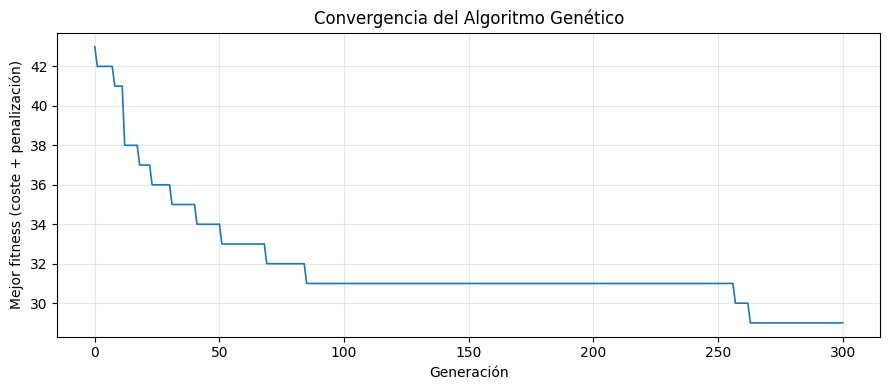

In [43]:
# ALGORITMO 1 — Heurística voraz (baseline)
def algoritmo_voraz_doblaje(matriz):
    """
    Heurística voraz con pre-ordenación por número de actores
    y asignación de mínimo incremento marginal por jornada.
    """
    # 1) Convertir cada toma a su conjunto de actores
    tomas_info = [(i, {a for a, p in enumerate(fila) if p == 1})
                  for i, fila in enumerate(matriz)]

    # 2) Ordenación: tomas con más actores primero
    tomas_info.sort(key=lambda x: len(x[1]), reverse=True)

    # 3) Asignación voraz
    dias = []                       # cada día: {'tomas': [...], 'actores': set(...)}
    for idx_toma, actores_toma in tomas_info:
        mejor_dia, menor_incremento = -1, float("inf")
        for i, dia in enumerate(dias):
            if len(dia["tomas"]) < 6:                          # capacidad
                nuevos = len(actores_toma - dia["actores"])
                if nuevos < menor_incremento:
                    menor_incremento, mejor_dia = nuevos, i

        if mejor_dia != -1:
            dias[mejor_dia]["tomas"].append(idx_toma)
            dias[mejor_dia]["actores"].update(actores_toma)
        else:
            dias.append({"tomas": [idx_toma], "actores": set(actores_toma)})

    return [d["tomas"] for d in dias]


# ALGORITMO 2 — Algoritmo Genético
def cromosoma_a_planificacion(cromosoma):
    """Agrupa los índices de las tomas por el día asignado en el cromosoma."""
    plan = {}
    for toma_idx, dia in enumerate(cromosoma):
        plan.setdefault(dia, []).append(toma_idx)
    return list(plan.values())

def fitness(cromosoma, matriz, max_tomas_dia=6, penalizacion_factor=1000):
    """
    fitness = coste real (actores únicos por día) + penalización por exceso.
    Penalización SEVERA: cualquier día con más de 6 tomas dispara un coste
    enorme que la presión selectiva eliminará en pocas generaciones.
    """
    plan = cromosoma_a_planificacion(cromosoma)
    coste, penalizacion = 0, 0
    for tomas_dia in plan:
        if len(tomas_dia) > max_tomas_dia:
            penalizacion += penalizacion_factor * (len(tomas_dia) - max_tomas_dia)
        actores = set()
        for t in tomas_dia:
            for a, p in enumerate(matriz[t]):
                if p == 1:
                    actores.add(a)
        coste += len(actores)
    return coste + penalizacion

# Operadores genéticos
def crear_individuo(n_tomas, dias_max):
    """Individuo aleatorio: cada gen es un día en [0, dias_max - 1]."""
    return [random.randint(0, dias_max - 1) for _ in range(n_tomas)]

def seleccion_torneo(poblacion, fitnesses, k=3):
    """Selecciona k candidatos al azar y devuelve UNA COPIA del mejor."""
    candidatos = random.sample(range(len(poblacion)), k)
    ganador = min(candidatos, key=lambda i: fitnesses[i])
    return poblacion[ganador][:]

def cruce_uniforme(p1, p2):
    """Cada gen se hereda de p1 o p2 con probabilidad 0.5."""
    h1, h2 = [], []
    for g1, g2 in zip(p1, p2):
        if random.random() < 0.5:
            h1.append(g1); h2.append(g2)
        else:
            h1.append(g2); h2.append(g1)
    return h1, h2

def mutacion(cromosoma, prob_mut, dias_max):
    """Cada gen se reasigna a un día aleatorio con probabilidad prob_mut."""
    return [random.randint(0, dias_max - 1) if random.random() < prob_mut else g
            for g in cromosoma]

# Bucle evolutivo
def algoritmo_genetico(matriz, n_tomas=30, dias_max=7,
                        tam_poblacion=150, generaciones=300,
                        prob_cruce=0.85, prob_mut=0.04,
                        torneo_k=3, elitismo=2, semilla=SEMILLA, verbose=True):
    """
    Devuelve (mejor_cromosoma, mejor_fitness, historial_de_fitness).
    """
    if semilla is not None:
        random.seed(semilla)

    # 1) Población inicial
    poblacion = [crear_individuo(n_tomas, dias_max) for _ in range(tam_poblacion)]
    fits = [fitness(ind, matriz) for ind in poblacion]

    # Mejor global
    idx_mejor = min(range(len(poblacion)), key=lambda i: fits[i])
    mejor_crom, mejor_fit = poblacion[idx_mejor][:], fits[idx_mejor]
    historial = [mejor_fit]

    if verbose:
        print(f"Gen   0  |  mejor fitness = {mejor_fit}")

    # 2) Bucle generacional
    for gen in range(1, generaciones + 1):
        # 2.a) Elitismo
        orden = sorted(range(len(poblacion)), key=lambda i: fits[i])
        nueva_pob = [poblacion[orden[i]][:] for i in range(elitismo)]

        # 2.b) Generación de hijos hasta completar la población
        while len(nueva_pob) < tam_poblacion:
            p1 = seleccion_torneo(poblacion, fits, torneo_k)
            p2 = seleccion_torneo(poblacion, fits, torneo_k)
            if random.random() < prob_cruce:
                h1, h2 = cruce_uniforme(p1, p2)
            else:
                h1, h2 = p1[:], p2[:]
            h1 = mutacion(h1, prob_mut, dias_max)
            h2 = mutacion(h2, prob_mut, dias_max)
            nueva_pob.append(h1)
            if len(nueva_pob) < tam_poblacion:
                nueva_pob.append(h2)

        # 2.c) Reemplazo y reevaluación
        poblacion = nueva_pob
        fits = [fitness(ind, matriz) for ind in poblacion]

        # 2.d) Actualizar mejor global
        idx = min(range(len(poblacion)), key=lambda i: fits[i])
        if fits[idx] < mejor_fit:
            mejor_fit, mejor_crom = fits[idx], poblacion[idx][:]
        historial.append(mejor_fit)

        if verbose and gen % 30 == 0:
            print(f"Gen {gen:3d}  |  mejor fitness = {mejor_fit}")

    return mejor_crom, mejor_fit, historial


# EJECUCIÓN SOBRE LAS 30 TOMAS REALES
print("=" * 56)
print("BASELINE — Algoritmo voraz")
print("=" * 56)
t0 = time.time()
plan_voraz = algoritmo_voraz_doblaje(matriz_tomas)
t1 = time.time()
coste_voraz = costo_total_planificacion(plan_voraz, matriz_tomas)
print(f"Días planificados: {len(plan_voraz)}")
print(f"Coste total (actores a pagar): {coste_voraz}")
print(f"Tiempo: {(t1-t0)*1000:.3f} ms")
print("\nPlanificación voraz:")
for i, dia in enumerate(plan_voraz):
    print(f"  Día {i+1}: tomas {dia}")

print("\n" + "=" * 56)
print("PROPUESTA PRINCIPAL — Algoritmo Genético")
print("=" * 56)
t0 = time.time()
mejor_crom, mejor_fit, historial = algoritmo_genetico(
    matriz_tomas,
    n_tomas=len(matriz_tomas),
    dias_max=7,
    tam_poblacion=150,
    generaciones=300,
    prob_cruce=0.85,
    prob_mut=0.04,
    torneo_k=3,
    elitismo=2,
    semilla=SEMILLA,
)
t1 = time.time()
plan_ag = cromosoma_a_planificacion(mejor_crom)
coste_ag = costo_total_planificacion(plan_ag, matriz_tomas)
es_valido = all(len(d) <= 6 for d in plan_ag)

print("\n----- Resultado AG -----")
print(f"Fitness final:        {mejor_fit}")
print(f"Coste real (Z):       {coste_ag}")
print(f"Días planificados:    {len(plan_ag)}")
print(f"Restricción válida:   {es_valido}  (todos los días con <=6 tomas)")
print(f"Tiempo total:         {(t1-t0):.2f} s")
print("\nPlanificación AG:")
for i, dia in enumerate(plan_ag):
    print(f"  Día {i+1} ({len(dia)} tomas): {sorted(dia)}")

# Comparativa
print("\n" + "=" * 56)
print("COMPARATIVA")
print("=" * 56)
print(f"Voraz : {coste_voraz} actores")
print(f"AG    : {coste_ag} actores")
mejora = coste_voraz - coste_ag
pct = (mejora / coste_voraz * 100) if coste_voraz > 0 else 0
print(f"Mejora del AG sobre el voraz: {mejora} actores  ({pct:.2f}%)")

# Gráfica de convergencia+
plt.figure(figsize=(9, 4))
plt.plot(historial, linewidth=1.2)
plt.title("Convergencia del Algoritmo Genético")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness (coste + penalización)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


(*)Calcula la complejidad del algoritmo

**Respuesta**

### Complejidad de la heurística voraz

El análisis paso a paso:

1. **Preprocesado:** construir el conjunto de actores de cada toma → $O(N\cdot A)$.
2. **Ordenación:** Timsort sobre $N$ tomas → $O(N\log N)$.
3. **Bucle principal:** $N$ tomas × $D$ días × $A$ actores (la resta de conjuntos recorre los $A$ actores) → $O(N\cdot D\cdot A)$.

Como $A=10$ es una constante pequeña y $D\le N$:

$$T_{vor}(N)\in O(N\log N + N\cdot D\cdot A)\ =\ O(N^{2})$$

**Polinómica (cuadrática)**, frente al $O(D^N)$ exponencial de la fuerza bruta. En la práctica resuelve las 30 tomas en menos de un milisegundo.

### Complejidad del Algoritmo Genético

El análisis paso a paso:

1. **Inicialización:** crear $P$ individuos de tamaño $N$ y evaluar fitness → $O(P\cdot N\cdot A)$.
2. **Bucle generacional ($G$ iteraciones):**
   - Ordenación para elitismo: $O(P\log P)$.
   - Generación de $P$ hijos: cada hijo requiere dos selecciones por torneo ($O(k)$), un cruce ($O(N)$), dos mutaciones ($O(N)$) y una evaluación de fitness ($O(N\cdot A)$). Total por generación: $O(P\cdot N\cdot A)$.

Por tanto:

$$T_{AG}(N)\in O\big(G\cdot P\cdot N\cdot A\big)$$

**Polinómica acotada por los hiperparámetros**. Con $G=300$, $P=150$, $N=30$, $A=10$: $\sim 1{,}35\times 10^{6}$ operaciones de fitness, ejecutables en segundos.

### Comparativa formal

| Algoritmo            | Complejidad                                       | Tipo de óptimo            | Tiempo $N=30$    |
|----------------------|---------------------------------------------------|---------------------------|------------------|
| Fuerza Bruta         | $O(D^{N}\cdot A)$ ≈ $O(|P^{\le 6}(N)|\cdot A)$    | Global garantizado        | $\sim 10^{13}$ años |
| Voraz (baseline)     | $O(N^{2})$                                        | Local (sin garantías)     | < 1 ms           |
| AG (propuesta)       | $O(G\cdot P\cdot N\cdot A)$                       | Aproximación global       | $\sim$ 1 s        |

El AG es más caro que el voraz pero sigue siendo **polinómico acotado**, y escapa de la miopía del voraz: mantiene diversidad mediante una población de 150 individuos, recombina información de soluciones distintas mediante el cruce uniforme, conserva el progreso mediante elitismo y penaliza con dureza las soluciones inadmisibles. La siguiente celda mide tiempos reales y evalúa la **robustez estadística** del AG con 10 semillas distintas para comprobar que la mejora sobre el voraz es sistemática y no fruto de una semilla afortunada.


In [ ]:
# MEDICIÓN DE TIEMPOS REALES
print("MEDICIÓN DE TIEMPOS — Voraz vs. AG")
print("-" * 56)

# Voraz
t0 = time.time()
_ = algoritmo_voraz_doblaje(matriz_tomas)
t1 = time.time()
print(f"Voraz:  {(t1-t0)*1000:.3f} ms")

# AG
t0 = time.time()
_ = algoritmo_genetico(matriz_tomas, semilla=SEMILLA, verbose=False)
t1 = time.time()
print(f"AG   :  {(t1-t0):.2f} s")

# ROBUSTEZ — AG ejecutado con 10 semillas distintas
print("\n" + "=" * 56)
print("ROBUSTEZ ESTADÍSTICA — AG con 10 semillas distintas")
print("=" * 56)

costes_ag = []
for s in range(10):
    crom, fit, _ = algoritmo_genetico(
        matriz_tomas, n_tomas=len(matriz_tomas), dias_max=7,
        tam_poblacion=150, generaciones=300,
        prob_cruce=0.85, prob_mut=0.04,
        torneo_k=3, elitismo=2, semilla=s, verbose=False)
    plan = cromosoma_a_planificacion(crom)
    coste = costo_total_planificacion(plan, matriz_tomas)
    valido = all(len(d) <= 6 for d in plan)
    costes_ag.append(coste)
    print(f"  semilla {s}:  coste = {coste:3d}   válido = {valido}")

print("-" * 56)
print(f"Voraz (baseline):       {coste_voraz}")
print(f"AG  mínimo  (10 runs):  {min(costes_ag)}")
print(f"AG  media   (10 runs):  {statistics.mean(costes_ag):.2f}")
print(f"AG  desv.tip(10 runs):  {statistics.pstdev(costes_ag):.2f}")
print(f"AG  máximo  (10 runs):  {max(costes_ag)}")
print(f"\nMejora media del AG sobre el voraz: "
      f"{coste_voraz - statistics.mean(costes_ag):.2f} actores")


MEDICIÓN DE TIEMPOS — Voraz vs. AG
--------------------------------------------------------
Voraz:  0.193 ms
AG   :  1.03 s

ROBUSTEZ ESTADÍSTICA — AG con 10 semillas distintas
  semilla 0:  coste =  30   válido = True
  semilla 1:  coste =  30   válido = True
  semilla 2:  coste =  31   válido = True


Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

**Respuesta**

Para comprobar que los algoritmos generalizan más allá de la instancia concreta del problema, se diseña un generador de guiones sintéticos. La función recibe el número de tomas, el número de actores y una probabilidad de aparición, y construye una matriz binaria con la misma estructura del dataset original.

Detalles del diseño:

- Cada celda $M[t][a]$ se rellena con un $1$ con probabilidad $p$ (`prob_aparicion`) y un $0$ con probabilidad $1-p$.
- Validación de seguridad: si por azar una fila se genera con suma $0$ (toma sin ningún actor, que no tiene sentido en el problema), se fuerza la inserción de un actor aleatorio para garantizar que toda toma tenga al menos un participante.
- Se acepta una semilla opcional para reproducibilidad.

El generador se utiliza para construir una "superproducción" simulada de **50 tomas y 15 actores** con densidad $0{,}25$, con la que se evaluará la escalabilidad de los dos algoritmos.


In [ ]:
def generar_guion_aleatorio(num_tomas, num_actores, prob_aparicion=0.3, semilla=None):
    """Matriz binaria sintética que simula una nueva película."""
    if semilla is not None:
        rnd = random.Random(semilla)
    else:
        rnd = random
    matriz = []
    for _ in range(num_tomas):
        toma = [1 if rnd.random() < prob_aparicion else 0
                for _ in range(num_actores)]
        # Validación: ninguna toma puede estar vacía
        if sum(toma) == 0:
            toma[rnd.randint(0, num_actores - 1)] = 1
        matriz.append(toma)
    return matriz

# Generamos una superproducción simulada
NUEVAS_TOMAS = 50
NUEVOS_ACTORES = 15
matriz_inventada = generar_guion_aleatorio(NUEVAS_TOMAS, NUEVOS_ACTORES,
                                            prob_aparicion=0.25, semilla=123)

print("NUEVO GUION SINTÉTICO")
print(f"  {len(matriz_inventada)} tomas × {len(matriz_inventada[0])} actores")
print("\nPrimeras 3 tomas:")
for i in range(3):
    print(f"  Toma {i+1}: {matriz_inventada[i]}")


Aplica el algoritmo al juego de datos generado

**Respuesta**

Se aplican **ambos algoritmos** (voraz y AG) al guion sintético generado. El objetivo es triple:

1. **Escalabilidad funcional:** comprobar que ni el voraz ni el AG están "ajustados" únicamente al dataset original — deben funcionar sobre cualquier matriz binaria con la misma estructura.
2. **Escalabilidad temporal:** verificar que los tiempos siguen siendo asumibles al crecer el tamaño (de 30×10 a 50×15).
3. **Consistencia de la mejora:** comprobar que el AG sigue superando al voraz cuando el problema se hace más grande y, por tanto, su espacio de búsqueda más complicado.

Para el AG, se aumenta el techo de días disponibles a $d_{\max}=11$ (por encima de $\lceil 50/6\rceil = 9$, dejando margen evolutivo) y se aumentan ligeramente el tamaño de población y el número de generaciones para acompañar al mayor espacio de búsqueda.


In [36]:
print("=" * 56)
print("APLICACIÓN A LOS DATOS SINTÉTICOS (50 tomas × 15 actores)")
print("=" * 56)

# 1) Voraz
t0 = time.time()
plan_voraz_rnd = algoritmo_voraz_doblaje(matriz_inventada)
t1 = time.time()
coste_voraz_rnd = costo_total_planificacion(plan_voraz_rnd, matriz_inventada)
print(f"\nVORAZ:")
print(f"  Días planificados: {len(plan_voraz_rnd)}")
print(f"  Coste total:       {coste_voraz_rnd}")
print(f"  Tiempo:            {(t1-t0)*1000:.2f} ms")

# 2) AG
t0 = time.time()
crom_rnd, fit_rnd, hist_rnd = algoritmo_genetico(
    matriz_inventada, n_tomas=NUEVAS_TOMAS, dias_max=11,
    tam_poblacion=200, generaciones=400,
    prob_cruce=0.85, prob_mut=0.03, torneo_k=3, elitismo=3,
    semilla=7, verbose=False)
t1 = time.time()
plan_ag_rnd = cromosoma_a_planificacion(crom_rnd)
coste_ag_rnd = costo_total_planificacion(plan_ag_rnd, matriz_inventada)
valido_rnd = all(len(d) <= 6 for d in plan_ag_rnd)
print(f"\nAG:")
print(f"  Días planificados: {len(plan_ag_rnd)}")
print(f"  Coste total:       {coste_ag_rnd}")
print(f"  Restricción válida: {valido_rnd}")
print(f"  Tiempo:            {(t1-t0):.2f} s")

print(f"\n----- Comparativa sobre datos sintéticos -----")
print(f"Voraz: {coste_voraz_rnd}   AG: {coste_ag_rnd}")
print(f"Mejora del AG: {coste_voraz_rnd - coste_ag_rnd} actores  "
      f"({(coste_voraz_rnd - coste_ag_rnd)/coste_voraz_rnd*100:.2f}%)")

# Planificación detallada del AG
print("\nPlanificación AG (datos sintéticos):")
for i, dia in enumerate(plan_ag_rnd):
    print(f"  Día {i+1} ({len(dia)} tomas): {sorted(dia)}")


APLICACIÓN A LOS DATOS SINTÉTICOS (50 tomas × 15 actores)

VORAZ:
  Días planificados: 9
  Coste total:       98
  Tiempo:            0.18 ms

AG:
  Días planificados: 9
  Coste total:       83
  Restricción válida: True
  Tiempo:            3.49 s

----- Comparativa sobre datos sintéticos -----
Voraz: 98   AG: 83
Mejora del AG: 15 actores  (15.31%)

Planificación AG (datos sintéticos):
  Día 1 (6 tomas): [0, 12, 18, 24, 27, 47]
  Día 2 (4 tomas): [1, 26, 28, 30]
  Día 3 (6 tomas): [2, 3, 8, 9, 11, 31]
  Día 4 (6 tomas): [4, 6, 19, 29, 37, 41]
  Día 5 (6 tomas): [5, 20, 22, 32, 34, 49]
  Día 6 (6 tomas): [7, 10, 25, 42, 45, 48]
  Día 7 (4 tomas): [13, 14, 17, 36]
  Día 8 (6 tomas): [15, 16, 23, 39, 40, 44]
  Día 9 (6 tomas): [21, 33, 35, 38, 43, 46]


Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

**Respuesta**

Para el diseño de los algoritmos, el marco combinatorio de particiones y el análisis de complejidad se ha consultado la siguiente bibliografía y documentación:

**Material de la asignatura:**
1. Universidad Internacional de Valencia (VIU). *03MIAR — Algoritmos de Optimización: Trabajo Práctico*. Material docente del Máster en Inteligencia Artificial.

**Combinatoria y particiones de conjuntos:**
2. Stanley, R. P. (2011). *Enumerative Combinatorics, Volume 1* (2.ª ed.). Cambridge University Press. (Capítulo 1 — Números de Stirling de Segunda Especie, particiones de conjuntos finitos.)
3. Graham, R. L., Knuth, D. E., & Patashnik, O. (1994). *Concrete Mathematics: A Foundation for Computer Science* (2.ª ed.). Addison-Wesley. (Capítulo 6 — Números de Stirling, Números de Bell y recurrencias.)
4. Rota, G.-C. (1964). *The Number of Partitions of a Set*. *The American Mathematical Monthly*, 71(5), 498–504.

**Algorítmica clásica:**
5. Brassard, G., & Bratley, P. (1997). *Fundamentos de Algoritmia*. Prentice Hall. (Algoritmos voraces, vuelta atrás y análisis de complejidad.)
6. Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2009). *Introduction to Algorithms* (3.ª ed.). MIT Press. (Greedy, backtracking y complejidades.)

**Metaheurísticas y Algoritmos Genéticos:**
7. Holland, J. H. (1992). *Adaptation in Natural and Artificial Systems*. MIT Press. (Obra fundacional de los Algoritmos Genéticos.)
8. Goldberg, D. E. (1989). *Genetic Algorithms in Search, Optimization and Machine Learning*. Addison-Wesley. (Operadores de selección, cruce y mutación; selección por torneo; elitismo.)
9. Eiben, A. E., & Smith, J. E. (2015). *Introduction to Evolutionary Computing* (2.ª ed.). Springer. (Diseño de funciones de aptitud con penalización; manejo de restricciones.)
10. Talbi, E.-G. (2009). *Metaheuristics: From Design to Implementation*. Wiley. (Comparativa formal de metaheurísticas y complejidades.)

**Set Partitioning y planificación:**
11. Balas, E., & Padberg, M. W. (1976). *Set Partitioning: A Survey*. *SIAM Review*, 18(4), 710–760.
12. Pinedo, M. L. (2016). *Scheduling: Theory, Algorithms, and Systems* (5.ª ed.). Springer. (Problemas de planificación con restricciones de capacidad.)

**Documentación técnica:**
13. Python Software Foundation. *Python 3 Language Reference*. https://docs.python.org/3/
14. Pandas Development Team. *Pandas Documentation*. https://pandas.pydata.org/
15. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. *Computing in Science & Engineering*, 9(3), 90–95.


Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

**Respuesta**

Posibles extensiones del trabajo, organizadas por su impacto sobre el modelo y por el incremento de complejidad asociado:

**1. Profundización en el repertorio metaheurístico.**

- **Recocido simulado (Simulated Annealing)** como alternativa de búsqueda local con escape probabilístico de mínimos locales. Útil para comparar con el AG en términos de coste/tiempo en este mismo espacio de particiones.
- **Algoritmos meméticos (AG + búsqueda local).** Aplicar un paso de búsqueda local (intercambio de tomas entre días) tras cada cruce/mutación. Sobre el espacio de particiones suele acelerar mucho la convergencia.
- **Inicialización informada.** Sembrar la población inicial del AG con la solución del voraz y con variantes perturbadas; esto suele reducir las generaciones necesarias a aproximadamente la mitad.

**2. Variaciones realistas del problema.**

- **Tarifas heterogéneas:** cada actor cobra un salario distinto. La función objetivo se reescribe como $Z = \sum_{j} \sum_{a\in A(B_j)} s_a$, donde $s_a$ es el salario diario del actor $a$. El esqueleto del AG no cambia, sólo la evaluación de fitness.
- **Restricciones de agenda:** disponibilidad por días de cada actor. Se añade una penalización adicional en el fitness por cada toma asignada a un día en el que algún actor de esa toma no está disponible.
- **Duración variable de las tomas:** sustituir la restricción "máximo 6 tomas/día" por "máximo $T_{\max}$ minutos/día", lo que convierte el problema en una variante de **Bin Packing con coste asociado a la composición del bin**.

**3. Escalabilidad a producciones grandes.**

- Para series de televisión con $N\sim 10^{4}$ tomas, conviene un **enfoque jerárquico** en dos fases: (a) clustering previo de tomas que comparten muchos actores (k-means sobre filas binarias, o clustering espectral); (b) aplicar el AG dentro de cada clúster. El acoplamiento entre clústers se resuelve mediante un meta-AG sobre la asignación de clústers a bloques de jornadas.

**4. Estudio empírico sistemático.**

- Diseño factorial sobre los hiperparámetros del AG ($P$, $G$, $p_c$, $p_m$, tamaño de torneo, $d_{\max}$) y análisis de varianza para identificar los más influyentes.
- Curvas de **trade-off coste vs. tiempo** sobre instancias de tamaños crecientes para caracterizar el régimen donde el AG aporta más respecto al voraz.

**5. Comparación con resolvedores exactos.**

- Formular el problema como **ILP (Integer Linear Programming)** con variables binarias $x_{tj}\in\{0,1\}$ (toma $t$ asignada al día $j$) y resolverlo con CPLEX/Gurobi/CBC sobre instancias de tamaño moderado ($N\le 30$). Esto da el óptimo global exacto y permite cuantificar el *gap* del AG frente al óptimo real, no sólo frente al voraz.
